In [1]:
import sys
import os
import torch
import pandas as pd
import numpy as np

PROJECT_DIR = r"D:\diabetic"

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


Using device: cuda


In [2]:
from src.dataset import DiabeticRetinopathyDataset
from src.transforms import val_transform
from torch.utils.data import DataLoader

CLEANED_DIR = os.path.join(
    PROJECT_DIR,
    "outputs",
    "cleaned"
)

TRAIN_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "train_images"
)

val_df = pd.read_csv(
    os.path.join(
        CLEANED_DIR,
        "validation_split.csv"
    )
)

val_dataset = DiabeticRetinopathyDataset(
    dataframe=val_df,
    image_dir=TRAIN_DIR,
    transform=val_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Validation images:", len(val_dataset))
print("Validation batches:", len(val_loader))

Validation images: 733
Validation batches: 184


In [3]:
from src.model import create_model

model = create_model(
    num_classes=5,
    pretrained=False
)

model = model.to(device)

print("Model created.")

Model created.


In [4]:
MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

best_model_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_best.pth"
)

checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Checkpoint loaded.")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])

Checkpoint loaded.
Checkpoint epoch: 6
Validation loss: 0.6956578248053908
Validation accuracy: 0.8294679399727148


In [5]:
from src.evaluate import get_predictions

true_labels, predicted_labels, probabilities = get_predictions(
    model,
    val_loader,
    device
)

print("True labels:", true_labels.shape)
print("Predictions:", predicted_labels.shape)
print("Probabilities:", probabilities.shape)

True labels: (733,)
Predictions: (733,)
Probabilities: (733, 5)


Confusion Matrix:
[[348  10   2   0   1]
 [  3  50  20   0   1]
 [  0  21 164  12   3]
 [  0   1  11  20   7]
 [  0   5  19   9  26]]


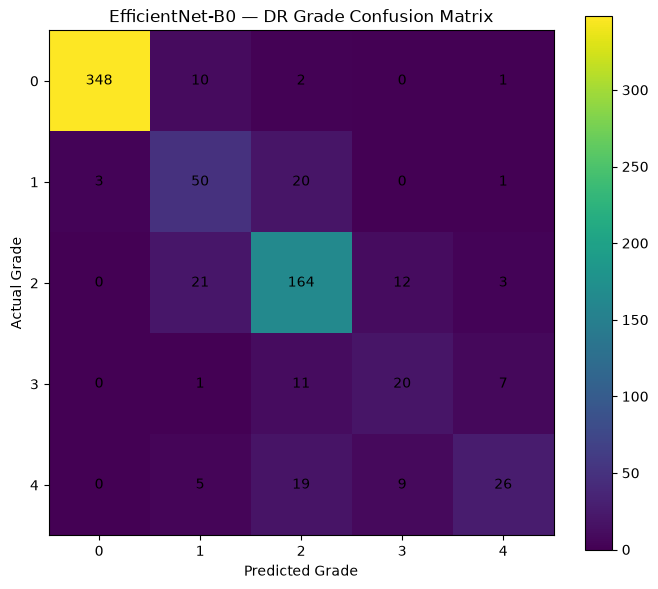

In [6]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2, 3, 4]
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("EfficientNet-B0 — DR Grade Confusion Matrix")
plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")

plt.xticks([0, 1, 2, 3, 4])
plt.yticks([0, 1, 2, 3, 4])

for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2, 3, 4],
    target_names=[
        "Grade 0",
        "Grade 1",
        "Grade 2",
        "Grade 3",
        "Grade 4"
    ],
    digits=4
)

print(report)

              precision    recall  f1-score   support

     Grade 0     0.9915    0.9640    0.9775       361
     Grade 1     0.5747    0.6757    0.6211        74
     Grade 2     0.7593    0.8200    0.7885       200
     Grade 3     0.4878    0.5128    0.5000        39
     Grade 4     0.6842    0.4407    0.5361        59

    accuracy                         0.8295       733
   macro avg     0.6995    0.6826    0.6846       733
weighted avg     0.8345    0.8295    0.8290       733



In [8]:
from sklearn.metrics import confusion_matrix

true_referable = (true_labels >= 2).astype(int)
pred_referable = (predicted_labels >= 2).astype(int)

referable_cm = confusion_matrix(
    true_referable,
    pred_referable,
    labels=[0, 1]
)

print("Referable DR Confusion Matrix:")
print(referable_cm)

Referable DR Confusion Matrix:
[[411  24]
 [ 27 271]]


In [9]:
tn, fp, fn, tp = referable_cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Sensitivity: 0.9093959731543624
Specificity: 0.9448275862068966


In [ ]:
# Step 23 — Dataset Test Set Verification

import os
import pandas as pd

PROJECT_DIR = r"D:\diabetic"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset"
)

TRAIN_DIR = os.path.join(
    DATASET_DIR,
    "train_images"
)

TEST_DIR = os.path.join(
    DATASET_DIR,
    "test_images"
)

TRAIN_CSV = os.path.join(
    DATASET_DIR,
    "train.csv"
)

TEST_CSV = os.path.join(
    DATASET_DIR,
    "test.csv"
)

train_df_full = pd.read_csv(TRAIN_CSV)
test_df_full = pd.read_csv(TEST_CSV)

train_image_files = [
    f for f in os.listdir(TRAIN_DIR)
    if f.lower().endswith(".png")
]

test_image_files = [
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(".png")
]

print("===== CSV COUNTS =====")
print("Train CSV rows:", len(train_df_full))
print("Test CSV rows:", len(test_df_full))

print("\n===== IMAGE COUNTS =====")
print("Train image files:", len(train_image_files))
print("Test image files:", len(test_image_files))

print("\n===== CSV COLUMNS =====")
print("Train CSV:", train_df_full.columns.tolist())
print("Test CSV:", test_df_full.columns.tolist())